In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/online_shopping.csv")

print("Dataset shape:", df.shape)

Dataset shape: (25000, 29)


In [3]:
# Check column names
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['customer_id', 'session_id', 'visit_date', 'device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'revenue', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased', 'cart_abandoned', 'rating', 'review_text', 'review_helpful_votes', 'payment_method', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'revenue_normalized', 'location']


In [4]:
# Check data types
print(df.dtypes)

customer_id                  int64
session_id                   int64
visit_date                     str
device_type                  int64
user_type                    int64
marketing_channel            int64
product_id                   int64
product_category             int64
unit_price                 float64
quantity                     int64
discount_percent             int64
discount_amount            float64
revenue                    float64
pages_viewed                 int64
time_on_site_sec             int64
added_to_cart                int64
purchased                    int64
cart_abandoned               int64
rating                       int64
review_text                  int64
review_helpful_votes         int64
payment_method               int64
visit_day                    int64
visit_month                  int64
visit_weekday                int64
visit_season                 int64
session_duration_bucket        str
revenue_normalized         float64
location            

In [5]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
customer_id                0
session_id                 0
visit_date                 0
device_type                0
user_type                  0
marketing_channel          0
product_id                 0
product_category           0
unit_price                 0
quantity                   0
discount_percent           0
discount_amount            0
revenue                    0
pages_viewed               0
time_on_site_sec           0
added_to_cart              0
purchased                  0
cart_abandoned             0
rating                     0
review_text                0
review_helpful_votes       0
payment_method             0
visit_day                  0
visit_month                0
visit_weekday              0
visit_season               0
session_duration_bucket    0
revenue_normalized         0
location                   0
dtype: int64


In [6]:
# Check duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
# Distribution of purchase intent

purchase_counts = df["purchased"].value_counts()

print("Purchase counts:")
print(purchase_counts)

print("\nPurchase percentages:")
print((purchase_counts / len(df) * 100).round(2))

Purchase counts:
purchased
0    19384
1     5616
Name: count, dtype: int64

Purchase percentages:
purchased
0    77.54
1    22.46
Name: count, dtype: float64


In [8]:
# Potential data leakage / post-outcome variables

possible_leakage = [
    "revenue",
    "payment_method",
    "cart_abandoned",
    "revenue_normalized"
]

print("Potential leakage columns:")
for col in possible_leakage:
    print("-", col)

Potential leakage columns:
- revenue
- payment_method
- cart_abandoned
- revenue_normalized


In [9]:
# Create a separate dataset for machine learning

df_model = df.drop(columns=possible_leakage)

print("Original dataset:", df.shape)
print("After removing leakage columns:", df_model.shape)

Original dataset: (25000, 29)
After removing leakage columns: (25000, 25)


In [10]:
# Customer/session IDs are identifiers, not useful behavioural predictors

id_columns = [
    "customer_id",
    "session_id"
]

df_model = df_model.drop(columns=id_columns)

print("Final modelling dataset shape:", df_model.shape)
print("\nFeatures:")
print(df_model.columns.tolist())

Final modelling dataset shape: (25000, 23)

Features:
['visit_date', 'device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased', 'rating', 'review_text', 'review_helpful_votes', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'location']


In [11]:
df_model.to_csv("../data/cleaned_online_shopping.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [12]:
# Convert visit_date to datetime format
df["visit_date"] = pd.to_datetime(
    df["visit_date"],
    format="%d-%m-%Y"
)

print(df["visit_date"].dtype)
print(df["visit_date"].min())
print(df["visit_date"].max())

datetime64[us]
2024-01-01 00:00:00
2024-12-30 00:00:00


In [13]:
categorical_columns = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "added_to_cart",
    "purchased",
    "cart_abandoned",
    "payment_method",
    "visit_weekday",
    "visit_season",
    "session_duration_bucket",
    "location"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts().sort_index())


device_type:
device_type
0     9887
1    12600
2     2513
Name: count, dtype: int64

user_type:
user_type
0    11218
1    13782
Name: count, dtype: int64

marketing_channel:
marketing_channel
0    4041
1    4190
2    4281
3    4116
4    4109
5    4263
Name: count, dtype: int64

product_category:
product_category
0    3142
1    3043
2    3237
3    3040
4    3204
5    3149
6    3112
7    3073
Name: count, dtype: int64

added_to_cart:
added_to_cart
0     8883
1    16117
Name: count, dtype: int64

purchased:
purchased
0    19384
1     5616
Name: count, dtype: int64

cart_abandoned:
cart_abandoned
0    14499
1    10501
Name: count, dtype: int64

payment_method:
payment_method
0    4227
1    4281
2    4051
3    4140
4    4229
5    4072
Name: count, dtype: int64

visit_weekday:
visit_weekday
0    3616
1    3587
2    3524
3    3630
4    3687
5    3489
6    3467
Name: count, dtype: int64

visit_season:
visit_season
0    6209
1    6247
2    6269
3    6275
Name: count, dtype: int64

session_dura

In [14]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
customer_id                0
session_id                 0
visit_date                 0
device_type                0
user_type                  0
marketing_channel          0
product_id                 0
product_category           0
unit_price                 0
quantity                   0
discount_percent           0
discount_amount            0
revenue                    0
pages_viewed               0
time_on_site_sec           0
added_to_cart              0
purchased                  0
cart_abandoned             0
rating                     0
review_text                0
review_helpful_votes       0
payment_method             0
visit_day                  0
visit_month                0
visit_weekday              0
visit_season               0
session_duration_bucket    0
revenue_normalized         0
location                   0
dtype: int64

Number of duplicate rows: 0


In [15]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
customer_id                0
session_id                 0
visit_date                 0
device_type                0
user_type                  0
marketing_channel          0
product_id                 0
product_category           0
unit_price                 0
quantity                   0
discount_percent           0
discount_amount            0
revenue                    0
pages_viewed               0
time_on_site_sec           0
added_to_cart              0
purchased                  0
cart_abandoned             0
rating                     0
review_text                0
review_helpful_votes       0
payment_method             0
visit_day                  0
visit_month                0
visit_weekday              0
visit_season               0
session_duration_bucket    0
revenue_normalized         0
location                   0
dtype: int64

Number of duplicate rows: 0


In [16]:
# Purchase distribution
print("Purchase distribution:")
print(df["purchased"].value_counts())

print("\nPurchase percentage:")
print(df["purchased"].value_counts(normalize=True) * 100)

Purchase distribution:
purchased
0    19384
1     5616
Name: count, dtype: int64

Purchase percentage:
purchased
0    77.536
1    22.464
Name: proportion, dtype: float64


In [17]:
# Columns that may cause data leakage
leakage_columns = [
    "revenue",
    "payment_method",
    "cart_abandoned",
    "revenue_normalized"
]

# Remove leakage columns
df_model = df.drop(columns=leakage_columns)

# Remove identifier columns
df_model = df_model.drop(columns=["customer_id", "session_id"])

print("Original shape:", df.shape)
print("Model dataset shape:", df_model.shape)

print("\nRemaining columns:")
print(df_model.columns.tolist())

Original shape: (25000, 29)
Model dataset shape: (25000, 23)

Remaining columns:
['visit_date', 'device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased', 'rating', 'review_text', 'review_helpful_votes', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'location']


In [18]:
# Statistical summary of numerical variables
df_model.describe().T

,count,mean,min,25%,50%,75%,max,std
visit_date,25000,2024-07-01 08:44:02.688000,2024-01-01 00:00:00,2024-03-31 00:00:00,2024-07-02 00:00:00,2024-10-01 00:00:00,2024-12-30 00:00:00,NaN
device_type,25000.0,0.70504,0.0,0.0,1.0,1.0,2.0,0.639543
user_type,25000.0,0.55128,0.0,0.0,1.0,1.0,1.0,0.497373
marketing_channel,25000.0,2.51404,0.0,1.0,2.0,4.0,5.0,1.704934
product_id,25000.0,449.107,0.0,225.0,448.0,675.0,898.0,259.513787
product_category,25000.0,3.49524,0.0,2.0,4.0,5.0,7.0,2.285053
unit_price,25000.0,782.31901,50.05,395.2225,691.725,1096.8425,1999.83,476.612168
quantity,25000.0,2.48904,1.0,1.0,2.0,3.0,4.0,1.114563
discount_percent,25000.0,8.9988,0.0,0.0,10.0,15.0,30.0,9.26364
discount_amount,25000.0,174.997669,0.0,0.0,65.815,240.355,2388.26,269.005411


In [19]:
# Purchase count
purchase_counts = df["purchased"].value_counts()

print("No Purchase (0):", purchase_counts[0])
print("Purchase (1):", purchase_counts[1])

No Purchase (0): 19384
Purchase (1): 5616


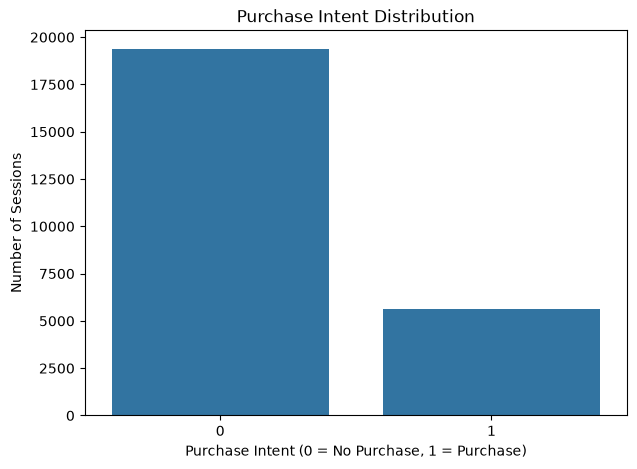

In [20]:
# Purchase distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="purchased")

plt.title("Purchase Intent Distribution")
plt.xlabel("Purchase Intent (0 = No Purchase, 1 = Purchase)")
plt.ylabel("Number of Sessions")

plt.show()

device_type
0    22.463841
1    22.317460
2    23.199363
Name: purchased, dtype: float64


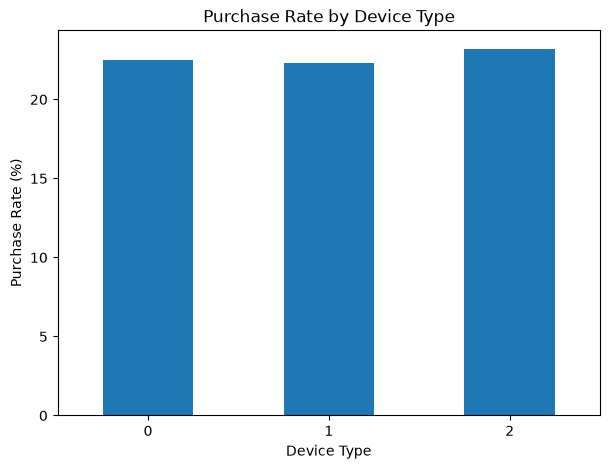

In [21]:
# Purchase rate by device type

device_purchase = df.groupby("device_type")["purchased"].mean() * 100

print(device_purchase)

plt.figure(figsize=(7, 5))

device_purchase.plot(kind="bar")

plt.title("Purchase Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Purchase Rate (%)")

plt.xticks(rotation=0)
plt.show()

user_type
0    18.550544
1    25.649398
Name: purchased, dtype: float64


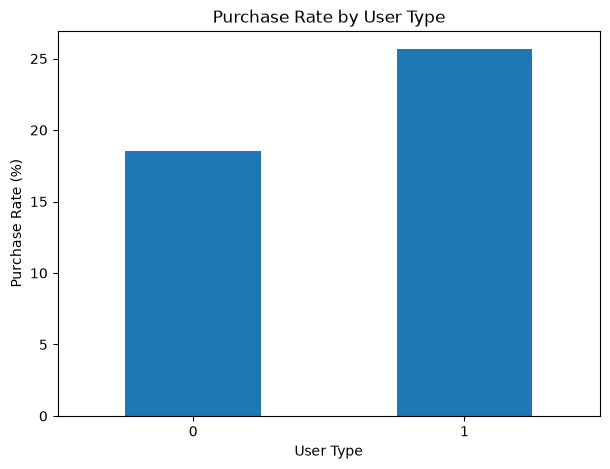

In [22]:
# Purchase rate by user type

user_purchase = df.groupby("user_type")["purchased"].mean() * 100

print(user_purchase)

plt.figure(figsize=(7, 5))
user_purchase.plot(kind="bar")

plt.title("Purchase Rate by User Type")
plt.xlabel("User Type")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)

plt.show()

marketing_channel
0    22.717149
1    22.124105
2    22.027564
3    22.643343
4    21.659771
5    23.598405
Name: purchased, dtype: float64


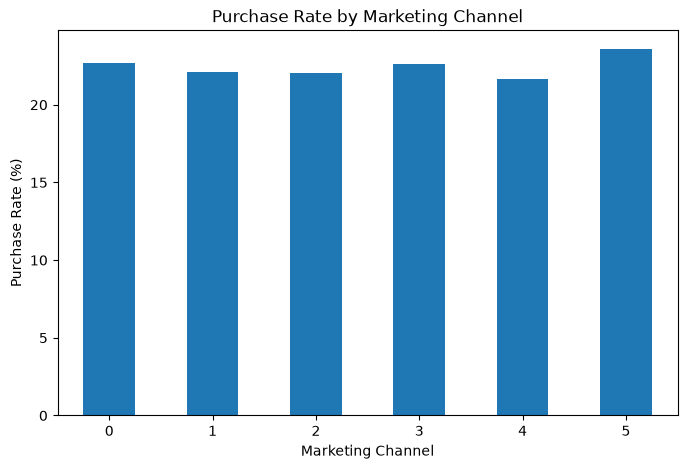

In [23]:
# Purchase rate by marketing channel

channel_purchase = df.groupby("marketing_channel")["purchased"].mean() * 100

print(channel_purchase)

plt.figure(figsize=(8, 5))
channel_purchase.plot(kind="bar")

plt.title("Purchase Rate by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [24]:
# Compare browsing behaviour for purchasers and non-purchasers

behavior_summary = df.groupby("purchased")[
    ["pages_viewed", "time_on_site_sec", "added_to_cart"]
].mean()

print(behavior_summary)

           pages_viewed  time_on_site_sec  added_to_cart
purchased                                               
0             12.512846        895.605809       0.541735
1             12.615207        929.691952       1.000000


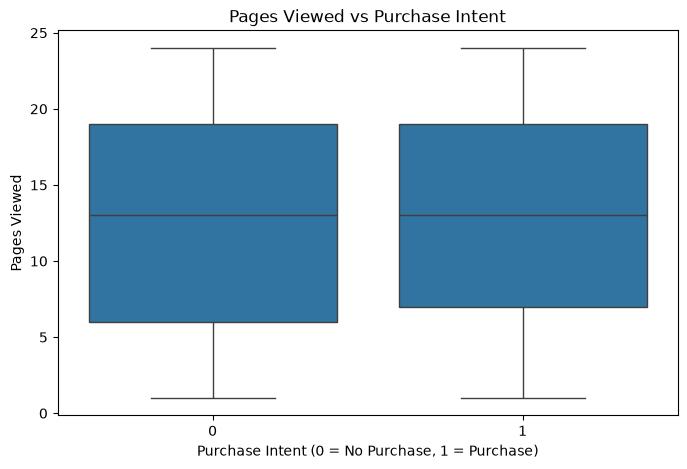

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="purchased",
    y="pages_viewed"
)

plt.title("Pages Viewed vs Purchase Intent")
plt.xlabel("Purchase Intent (0 = No Purchase, 1 = Purchase)")
plt.ylabel("Pages Viewed")

plt.show()

added_to_cart
0     0.000000
1    34.845195
Name: purchased, dtype: float64


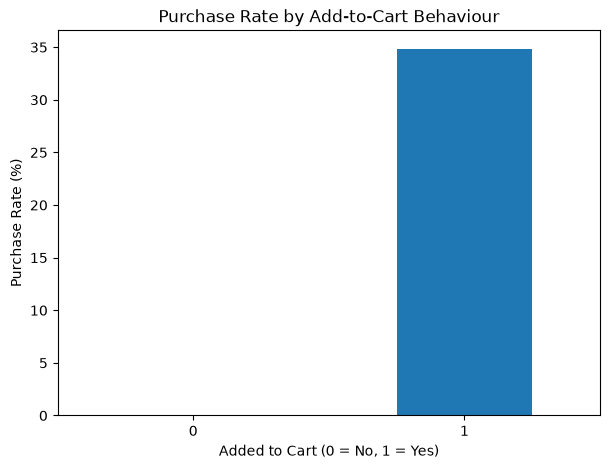

In [26]:
# Purchase rate based on whether the item was added to cart

cart_purchase = df.groupby("added_to_cart")["purchased"].mean() * 100

print(cart_purchase)

plt.figure(figsize=(7, 5))
cart_purchase.plot(kind="bar")

plt.title("Purchase Rate by Add-to-Cart Behaviour")
plt.xlabel("Added to Cart (0 = No, 1 = Yes)")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)

plt.show()

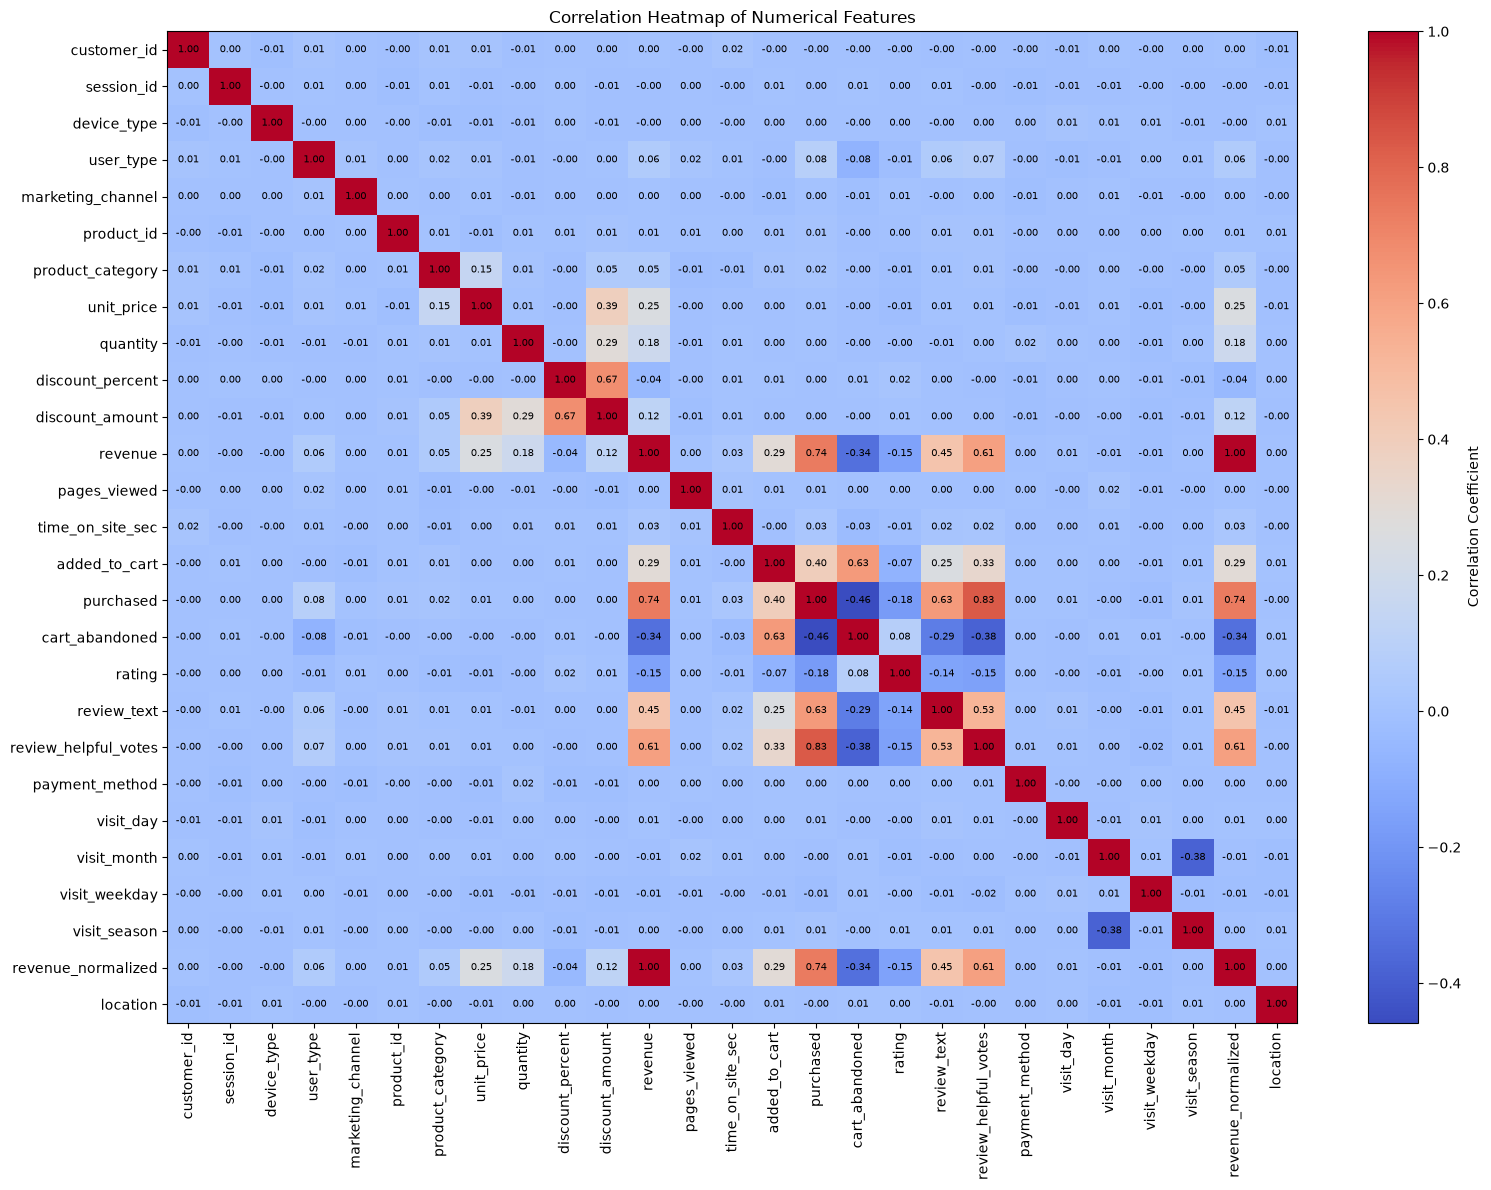

In [59]:
# Select numerical columns and calculate the correlation matrix
numeric_df = df.select_dtypes(include=["number"])
correlation_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 12))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation Coefficient")

plt.xticks(
  range(len(correlation_matrix.columns)),
  correlation_matrix.columns,
  rotation=90
)
plt.yticks(
  range(len(correlation_matrix.columns)),
  correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
  for j in range(len(correlation_matrix.columns)):
    plt.text(
      j,
      i,
      f"{correlation_matrix.iloc[i, j]:.2f}",
      ha="center",
      va="center",
      fontsize=7
    )

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [27]:
cart_purchase = df.groupby("added_to_cart")["purchased"].mean() * 100

print("Purchase Rate:")
print("No Add to Cart (0):", cart_purchase[0], "%")
print("Added to Cart (1):", cart_purchase[1], "%")

Purchase Rate:
No Add to Cart (0): 0.0 %
Added to Cart (1): 34.84519451510827 %


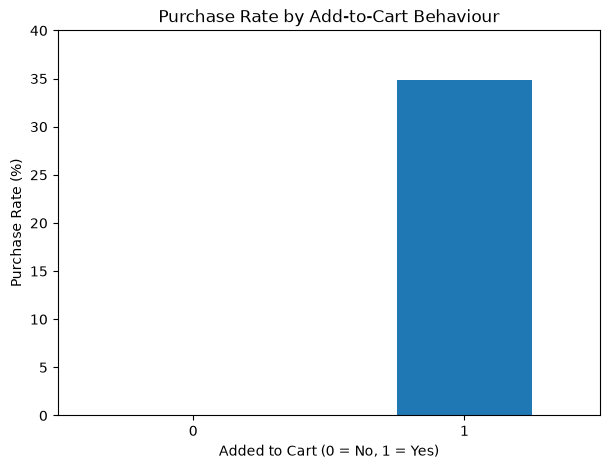

In [28]:
cart_purchase = df.groupby("added_to_cart")["purchased"].mean() * 100

plt.figure(figsize=(7, 5))
cart_purchase.plot(kind="bar")

plt.title("Purchase Rate by Add-to-Cart Behaviour")
plt.xlabel("Added to Cart (0 = No, 1 = Yes)")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 40)

plt.show()

Purchase Rate by Session Duration:
session_duration_bucket
Long          23.616885
Short         22.787043
Very Long     23.221154
Very Short    20.239234
Name: purchased, dtype: float64


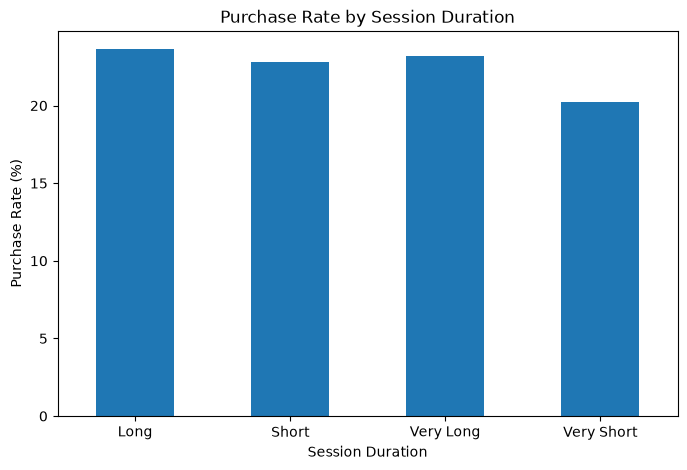

In [29]:
duration_purchase = df.groupby("session_duration_bucket")["purchased"].mean() * 100

print("Purchase Rate by Session Duration:")
print(duration_purchase)

plt.figure(figsize=(8, 5))
duration_purchase.plot(kind="bar")

plt.title("Purchase Rate by Session Duration")
plt.xlabel("Session Duration")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)

plt.show()

Purchase Rate by Product Category:
product_category
0    22.278803
1    21.261913
2    22.273710
3    20.756579
4    22.690387
5    23.118450
6    24.678663
7    22.583794
Name: purchased, dtype: float64


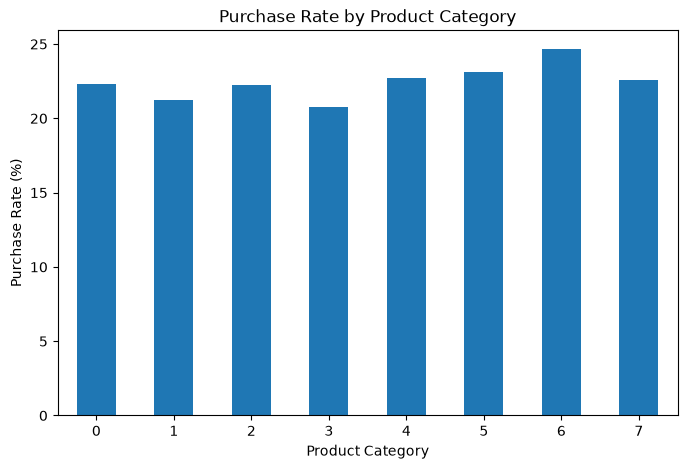

In [30]:
category_purchase = df.groupby("product_category")["purchased"].mean() * 100

print("Purchase Rate by Product Category:")
print(category_purchase)

plt.figure(figsize=(8, 5))
category_purchase.plot(kind="bar")

plt.title("Purchase Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)

plt.show()

Purchase Rate by Weekday:
visit_weekday
0    22.759956
1    23.445776
2    22.928490
3    22.589532
4    22.457282
5    21.668100
6    21.344102
Name: purchased, dtype: float64


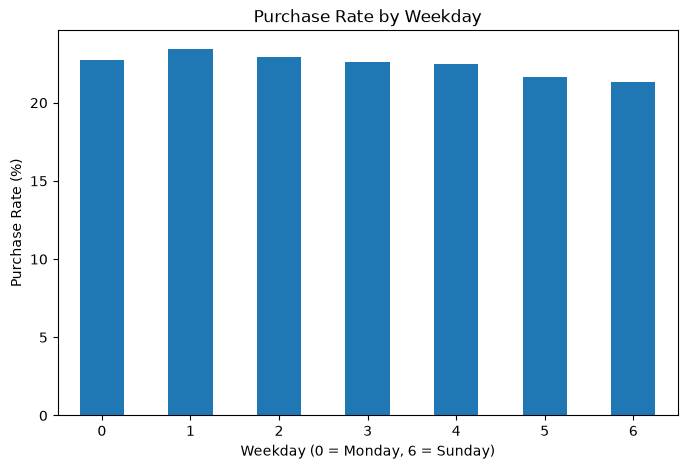

In [31]:
weekday_purchase = df.groupby("visit_weekday")["purchased"].mean() * 100

print("Purchase Rate by Weekday:")
print(weekday_purchase)

plt.figure(figsize=(8, 5))
weekday_purchase.plot(kind="bar")

plt.title("Purchase Rate by Weekday")
plt.xlabel("Weekday (0 = Monday, 6 = Sunday)")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)

plt.show()

Purchase Rate by Season:
visit_season
0    21.935900
1    22.154634
2    22.762801
3    22.996016
Name: purchased, dtype: float64


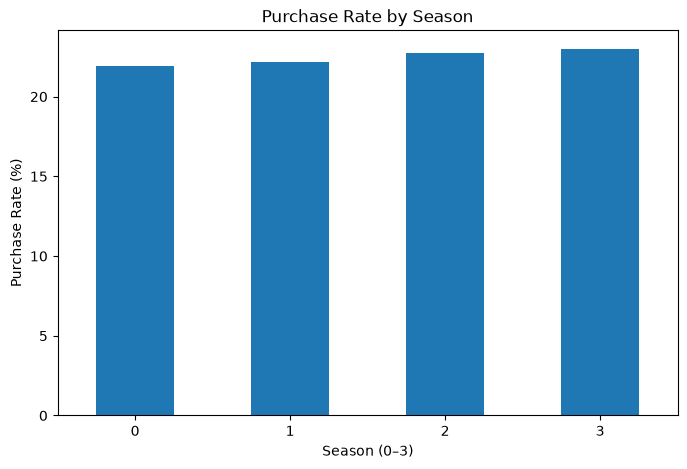

In [32]:
season_purchase = df.groupby("visit_season")["purchased"].mean() * 100

print("Purchase Rate by Season:")
print(season_purchase)

plt.figure(figsize=(8, 5))
season_purchase.plot(kind="bar")

plt.title("Purchase Rate by Season")
plt.xlabel("Season (0–3)")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=0)

plt.show()

Average Unit Price by Purchase Intent:
purchased
0    780.122807
1    789.899354
Name: unit_price, dtype: float64


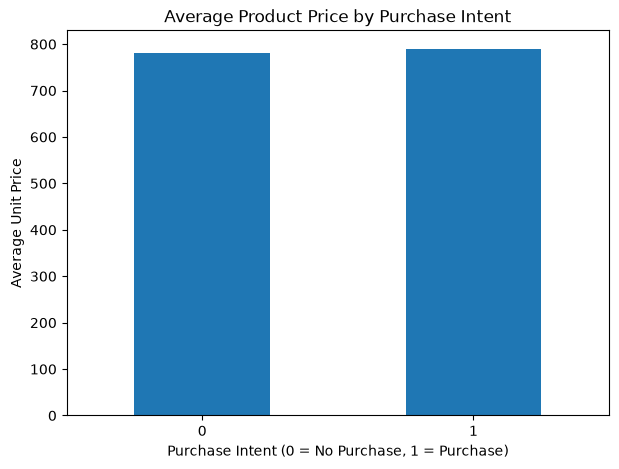

In [33]:
price_purchase = df.groupby("purchased")["unit_price"].mean()

print("Average Unit Price by Purchase Intent:")
print(price_purchase)

plt.figure(figsize=(7, 5))
price_purchase.plot(kind="bar")

plt.title("Average Product Price by Purchase Intent")
plt.xlabel("Purchase Intent (0 = No Purchase, 1 = Purchase)")
plt.ylabel("Average Unit Price")
plt.xticks(rotation=0)

plt.show()

Average Time on Site by Purchase Intent:
purchased
0    895.605809
1    929.691952
Name: time_on_site_sec, dtype: float64


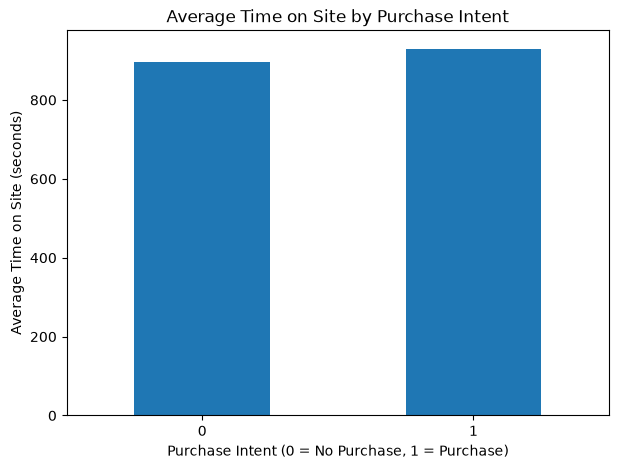

In [34]:
time_purchase = df.groupby("purchased")["time_on_site_sec"].mean()

print("Average Time on Site by Purchase Intent:")
print(time_purchase)

plt.figure(figsize=(7, 5))
time_purchase.plot(kind="bar")

plt.title("Average Time on Site by Purchase Intent")
plt.xlabel("Purchase Intent (0 = No Purchase, 1 = Purchase)")
plt.ylabel("Average Time on Site (seconds)")
plt.xticks(rotation=0)

plt.show()

In [35]:
correlation = df.select_dtypes(include="number").corr()["purchased"].sort_values(ascending=False)

print("Correlation with Purchase Intent:")
print(correlation)


Correlation with Purchase Intent:
purchased               1.000000
review_helpful_votes    0.831446
revenue_normalized      0.735319
revenue                 0.735319
review_text             0.631109
added_to_cart           0.399604
user_type               0.084599
time_on_site_sec        0.027427
product_category        0.015382
product_id              0.011208
visit_season            0.010146
unit_price              0.008561
visit_day               0.007924
pages_viewed            0.006165
payment_method          0.004630
marketing_channel       0.004506
quantity                0.004175
discount_amount         0.003144
device_type             0.002772
session_id              0.002020
discount_percent        0.001322
customer_id            -0.000577
location               -0.001429
visit_month            -0.004049
visit_weekday          -0.014006
rating                 -0.178751
cart_abandoned         -0.458077
Name: purchased, dtype: float64


In [36]:
review_features = df.groupby("purchased")[
    ["review_text", "review_helpful_votes", "rating"]
].mean()

print("Review-related Features by Purchase Intent:")
print(review_features)

Review-related Features by Purchase Intent:
           review_text  review_helpful_votes    rating
purchased                                             
0             1.000000              0.000000  4.000000
1             4.004274             24.576211  3.768519


In [37]:
leakage_columns = [
    "revenue",
    "revenue_normalized",
    "payment_method",
    "cart_abandoned",
    "review_text",
    "review_helpful_votes"
]

df_model = df.drop(columns=leakage_columns)

print("Columns after removing leakage:")
print(df_model.columns.tolist())

Columns after removing leakage:
['customer_id', 'session_id', 'visit_date', 'device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased', 'rating', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'location']


In [38]:
print("Model dataset shape:", df_model.shape)

print("\nRemaining columns:")
print(df_model.columns.tolist())

Model dataset shape: (25000, 23)

Remaining columns:
['customer_id', 'session_id', 'visit_date', 'device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased', 'rating', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'location']


In [39]:
df_model = df_model.drop(columns=["customer_id", "session_id"])

print("Shape after removing ID columns:", df_model.shape)
print("\nRemaining columns:")
print(df_model.columns.tolist())

Shape after removing ID columns: (25000, 21)

Remaining columns:
['visit_date', 'device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased', 'rating', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'location']


In [40]:
# Extract useful date features
df_model["visit_year"] = df_model["visit_date"].dt.year
df_model["visit_month"] = df_model["visit_date"].dt.month
df_model["visit_day"] = df_model["visit_date"].dt.day
df_model["visit_weekday"] = df_model["visit_date"].dt.weekday

# Remove the original date column
df_model = df_model.drop(columns=["visit_date"])

print("Shape:", df_model.shape)
print("\nColumns:")
print(df_model.columns.tolist())

Shape: (25000, 21)

Columns:
['device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased', 'rating', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'location', 'visit_year']


In [41]:
# Separate features and target
X = df_model.drop(columns=["purchased"])
y = df_model["purchased"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (25000, 20)
Target shape: (25000,)

Target distribution:
purchased
0    19384
1     5616
Name: count, dtype: int64


In [43]:
# Categorical features
categorical_features = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_id",
    "product_category",
    "added_to_cart",
    "visit_weekday",
    "visit_season",
    "session_duration_bucket",
    "location"
]

# Numerical features
numerical_features = [
    "unit_price",
    "quantity",
    "discount_percent",
    "discount_amount",
    "pages_viewed",
    "time_on_site_sec",
    "rating",
    "visit_day",
    "visit_month",
    "visit_year"
]

print("Categorical features:", len(categorical_features))
print(categorical_features)

print("\nNumerical features:", len(numerical_features))
print(numerical_features)

Categorical features: 10
['device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'added_to_cart', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'location']

Numerical features: 10
['unit_price', 'quantity', 'discount_percent', 'discount_amount', 'pages_viewed', 'time_on_site_sec', 'rating', 'visit_day', 'visit_month', 'visit_year']


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training features: (20000, 20)
Testing features: (5000, 20)

Training target distribution:
purchased
0    15507
1     4493
Name: count, dtype: int64

Testing target distribution:
purchased
0    3877
1    1123
Name: count, dtype: int64


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing for numerical features
numerical_transformer = StandardScaler()

# Preprocessing for categorical features
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine both preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Make predictions
y_pred = logistic_model.predict(X_test)

# Probability predictions for ROC-AUC
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Performance
--------------------------------
Accuracy : 0.6234
Precision: 0.3540
Recall   : 0.8201
F1-Score : 0.4945
ROC-AUC  : 0.7579

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.57      0.70      3877
           1       0.35      0.82      0.49      1123

    accuracy                           0.62      5000
   macro avg       0.63      0.69      0.60      5000
weighted avg       0.79      0.62      0.65      5000



In [48]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [49]:
y_pred_rf = random_forest_model.predict(X_test)
y_pred_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("Random Forest Performance")
print("--------------------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
--------------------------------
Accuracy : 0.9204
Precision: 0.9814
Recall   : 0.6581
F1-Score : 0.7878
ROC-AUC  : 0.9131

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      3877
           1       0.98      0.66      0.79      1123

    accuracy                           0.92      5000
   macro avg       0.95      0.83      0.87      5000
weighted avg       0.93      0.92      0.91      5000



In [50]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, accuracy_rf],
    "Precision": [precision, precision_rf],
    "Recall": [recall, recall_rf],
    "F1-Score": [f1, f1_rf],
    "ROC-AUC": [roc_auc, roc_auc_rf]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6234,0.353958,0.820125,0.494497,0.757869
1,Random Forest,0.9204,0.981408,0.658059,0.787846,0.913115


Confusion Matrix:
[[3863   14]
 [ 384  739]]


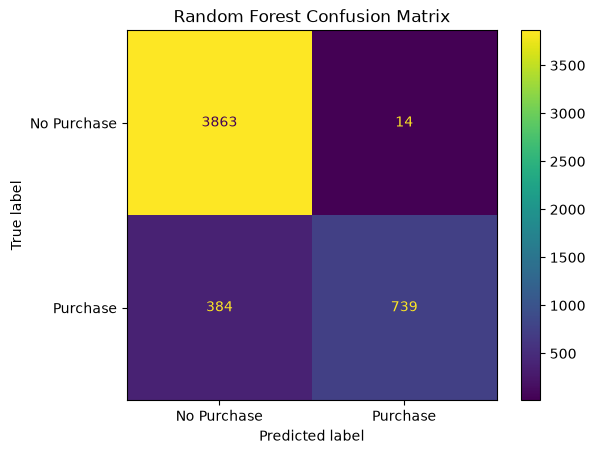

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Purchase", "Purchase"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

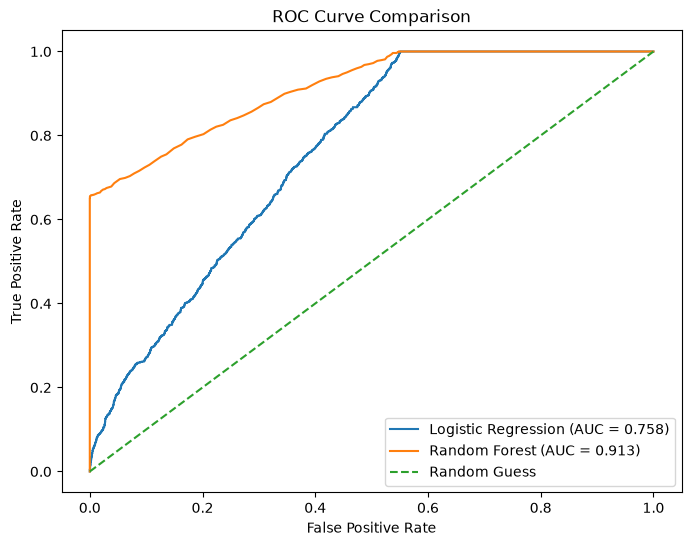

In [52]:
from sklearn.metrics import roc_curve

# ROC curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)

# ROC curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [53]:
# Get the trained Random Forest components
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_classifier = random_forest_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = rf_preprocessor.get_feature_names_out()

# Get feature importance values
importances = rf_classifier.feature_importances_

# Create a DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Display top 15 features
feature_importance.head(15)

,Feature,Importance
6,num__rating,0.215730
929,cat__added_to_cart_1,0.130245
928,cat__added_to_cart_0,0.104815
5,num__time_on_site_sec,0.028841
0,num__unit_price,0.028463
7,num__visit_day,0.022456
4,num__pages_viewed,0.021700
3,num__discount_amount,0.020794
8,num__visit_month,0.016803
2,num__discount_percent,0.013202


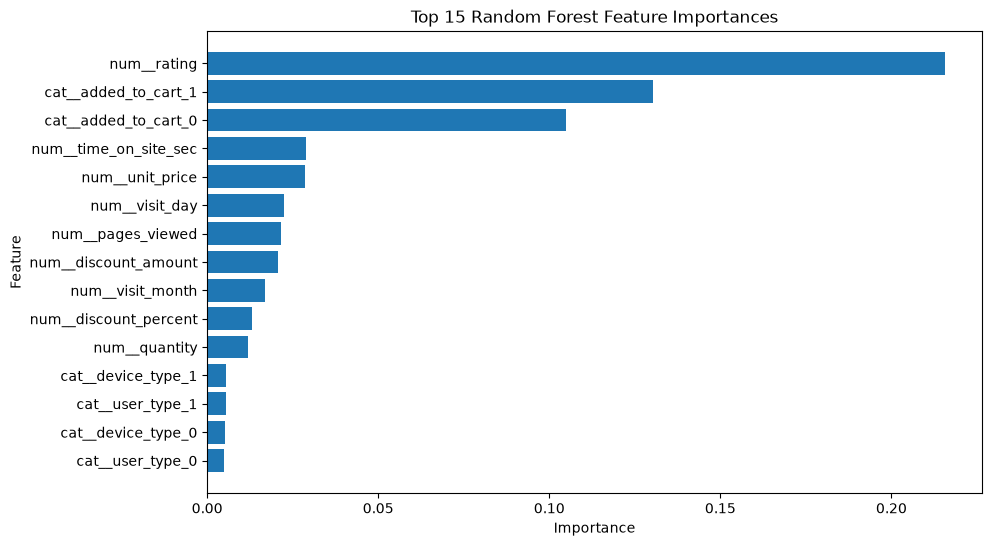

In [54]:
# Select top 15 features
top_features = feature_importance.head(15).sort_values("Importance")

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.show()

In [55]:
import joblib

# Save the trained Random Forest model
joblib.dump(
    random_forest_model,
    "../models/random_forest_purchase_intent_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [56]:
# Save the cleaned and prepared dataset
df_model.to_csv(
    "../data/cleaned_online_shopping.csv",
    index=False
)

print("Cleaned dataset saved successfully!")
print("Shape:", df_model.shape)

Cleaned dataset saved successfully!
Shape: (25000, 21)


In [57]:
# Final model comparison
final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, accuracy_rf],
    "Precision": [precision, precision_rf],
    "Recall": [recall, recall_rf],
    "F1-Score": [f1, f1_rf],
    "ROC-AUC": [roc_auc, roc_auc_rf]
})

print("Final Model Comparison")
print("----------------------")
display(final_results)

Final Model Comparison
----------------------


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6234,0.353958,0.820125,0.494497,0.757869
1,Random Forest,0.9204,0.981408,0.658059,0.787846,0.913115


In [58]:
print("Best Model: Random Forest")
print(f"Accuracy : {accuracy_rf:.2%}")
print(f"Precision: {precision_rf:.2%}")
print(f"Recall   : {recall_rf:.2%}")
print(f"F1-Score : {f1_rf:.2%}")
print(f"ROC-AUC  : {roc_auc_rf:.2%}")


Best Model: Random Forest
Accuracy : 92.04%
Precision: 98.14%
Recall   : 65.81%
F1-Score : 78.78%
ROC-AUC  : 91.31%


## Final Findings

- The dataset contains 25,000 online shopping sessions and 29 original features.
- The target variable is `purchased`, where 1 represents a purchase and 0 represents no purchase.
- The dataset contains 19,384 non-purchase sessions (77.54%) and 5,616 purchase sessions (22.46%).
- Missing values and duplicate rows were not found in the dataset.
- Post-outcome and leakage-prone variables such as revenue, payment method, cart abandonment, and review-related variables were excluded from model training.
- Exploratory analysis showed that customer behaviour, particularly add-to-cart activity and session-related behaviour, provides useful information for purchase prediction.
- Two classification models were evaluated: Logistic Regression and Random Forest.
- Random Forest achieved the best overall performance with 92.04% accuracy, 98.14% precision, 65.81% recall, 78.78% F1-score, and 91.31% ROC-AUC.
- Logistic Regression achieved 62.34% accuracy and 75.79% ROC-AUC.
- Random Forest provided substantially stronger overall predictive performance than Logistic Regression.
- The model can potentially support targeted marketing and customer engagement by identifying sessions with a higher likelihood of purchase.